In [2]:
#Librerias
import matplotlib.pyplot as plt
import numpy as np
#%pip install wordcloud
from wordcloud import WordCloud


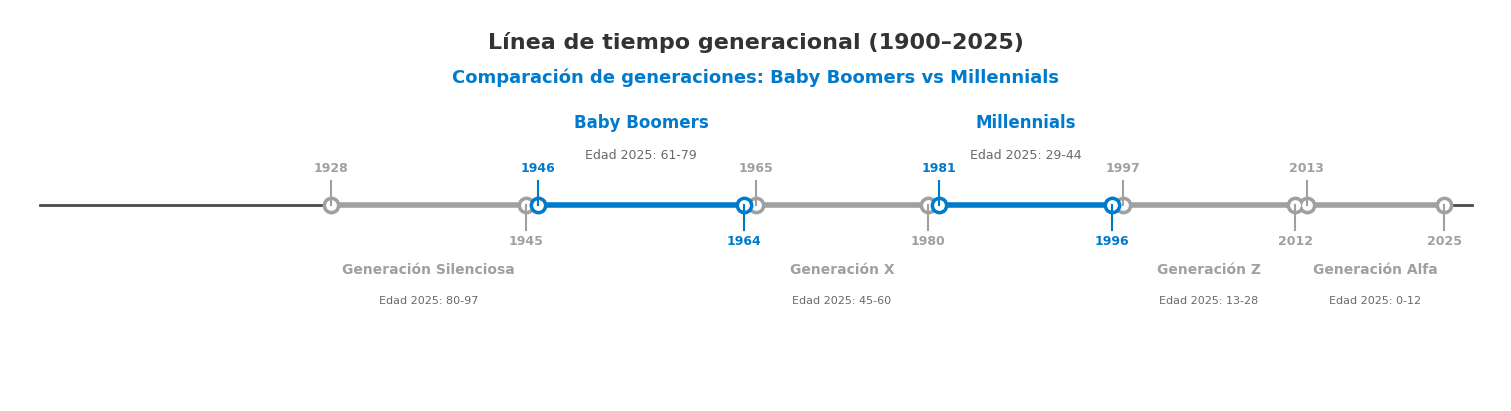

In [ ]:
# Visualización de líneas de tiempo generacionales


# idea original de https://www.kaggle.com/code/joshuaswords/netflix-data-visualization

# Modificación para incluir generaciones

# Datos de generaciones
generaciones = [
    ("Generación Silenciosa", 1928, 1945),
    ("Baby Boomers", 1946, 1964),
    ("Generación X", 1965, 1980),
    ("Millennials", 1981, 1996),
    ("Generación Z", 1997, 2012),
    ("Generación Alfa", 2013, 2025)
]

year_now = 2025
edades = [(year_now - fin, year_now - inicio) for _, inicio, fin in generaciones]

# Configurar figura
fig, ax = plt.subplots(figsize=(15, 4), constrained_layout=True)
ax.set_ylim(-2, 2)
ax.set_xlim(1900, 2030)

# Línea base
ax.axhline(0, xmin=0.02, xmax=0.98, color="#4a4a4a", lw=2, zorder=1)

# Función para color según generación
def color_gen(nombre):
    if nombre in ["Baby Boomers", "Millennials"]:
        return "#007ACC"  # azul
    else:
        return "#A0A0A0"  # gris

# Dibujar puntos, líneas y textos
for (nombre, inicio, fin), (edad_min, edad_max) in zip(generaciones, edades):
    color = color_gen(nombre)
    z = 5 if nombre in ["Baby Boomers", "Millennials"] else 3

    # Línea del periodo
    ax.plot([inicio, fin], [0, 0], color=color, lw=4, zorder=z)

    # Círculos
    ax.scatter([inicio, fin], [0, 0], s=140, color=color, zorder=z + 1)
    ax.scatter([inicio, fin], [0, 0], s=45, color="white", zorder=z + 2)

    # Líneas verticales con el año
    for x, pos in zip([inicio, fin], ["up", "down"]):
        ax.plot([x, x], [0, -0.25 if pos == "down" else 0.25], color=color, lw=1.5, zorder=z + 3)
        ax.text(x, -0.4 if pos == "down" else 0.35, str(x), ha='center',
                fontsize=9, color=color, fontweight='bold')

    # Texto de generación
    if nombre in ["Baby Boomers", "Millennials"]:
        ax.text((inicio + fin) / 2, 0.75, nombre, ha='center', va='bottom',
                fontsize=12, fontweight='bold', color=color)
        ax.text((inicio + fin) / 2, 0.45, f"Edad 2025: {edad_min}-{edad_max}",
                ha='center', va='bottom', fontsize=9, color='dimgray')
    else:
        ax.text((inicio + fin) / 2, -0.7, nombre, ha='center',
                fontsize=10, fontweight='bold', color=color)
        ax.text((inicio + fin) / 2, -1.0, f"Edad 2025: {edad_min}-{edad_max}",
                ha='center', fontsize=8, color='dimgray')

# --- Títulos ---
ax.text(1965, 1.6, "Línea de tiempo generacional (1900–2025)",
        fontsize=16, fontweight='bold', color="#333333", ha='center')
ax.text(1965, 1.25, "Comparación de generaciones: Baby Boomers vs Millennials",
        fontsize=13, fontweight='bold', color="#007ACC", ha='center')

# Limpieza visual
ax.set_xticks([])  # quitar eje X
ax.set_yticks([])
for spine in ["left", "top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.show()


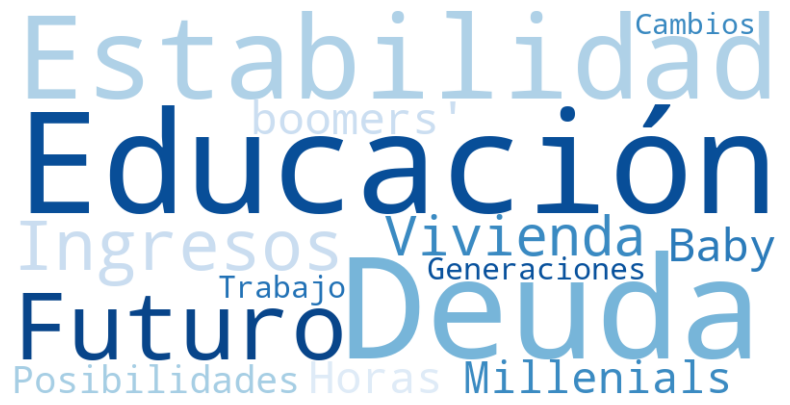

In [3]:


# word cloud example

#idea original de  de este link saque la de word cloud
#https://www.datacamp.com/tutorial/wordcloud-python


text = "Educación Deuda Estabilidad Futuro Ingresos Vivienda 'Baby boomers' Millenials Horas Posibilidades Generaciones Trabajo Cambios"
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text) #, colormap='Oranges'

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("../images/wordcloud_blues.png", format="png")
plt.show()

In [11]:
#Base world population :https://www.kaggle.com/datasets/whenamancodes/world-population-live-dataset
#importar un csv en pandas
import pandas as pd
df = pd.read_csv('../resources/world_population.csv')
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CCA3                         233 non-null    object 
 1   Name                         234 non-null    object 
 2   2022                         234 non-null    int64  
 3   2020                         234 non-null    int64  
 4   2015                         234 non-null    int64  
 5   2010                         234 non-null    int64  
 6   2000                         234 non-null    int64  
 7   1990                         234 non-null    int64  
 8   1980                         234 non-null    int64  
 9   1970                         234 non-null    int64  
 10  Area (km²)                   234 non-null    int64  
 11  Density (per km²)            234 non-null    float64
 12  GrowthRate                   234 non-null    float64
 13  World Population Per

In [12]:
# Detectar columnas numéricas que representan años
year_cols = [col for col in df.columns if col.isdigit()]

# Derretir el dataframe usando solo esas columnas
df_long = df.melt(
    id_vars=[col for col in df.columns if col not in year_cols],
    value_vars=year_cols,
    var_name="Year",
    value_name="Population"
)

# Convertir Year a entero
df_long["Year"] = df_long["Year"].astype(int)

# Agrupar por año y sumar
df_total = df_long.groupby("Year", as_index=False)["Population"].sum().sort_values("Year")

print(df_total.head(8))

   Year  Population
0  1970     3694129
1  1980     4442407
2  1990     5314196
3  2000     6147055
4  2010     6983783
5  2015     7424808
6  2020     7839255
7  2022     7973413


In [13]:
#Agregar una fila para año 2025 y poblacion 8.3 billones
df_total = pd.concat([df_total, pd.DataFrame({"Year": [2025], "Population": [8300000]})], ignore_index=True)


In [14]:
df_total.head(10)

,Year,Population
0,1970,3694129
1,1980,4442407
2,1990,5314196
3,2000,6147055
4,2010,6983783
5,2015,7424808
6,2020,7839255
7,2022,7973413
8,2025,8300000


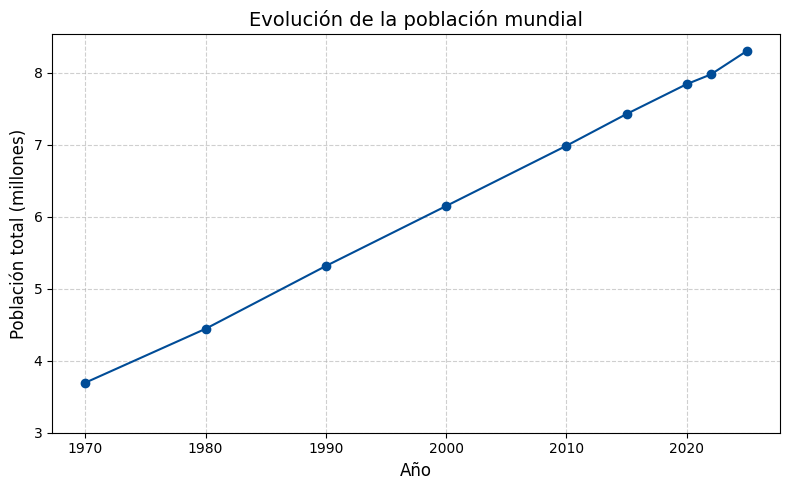

In [15]:
#Prueba de visualización de la población mundial a lo largo del tiempo

plt.figure(figsize=(8,5))

# Escalamos la población a millones
plt.plot(df_total["Year"], df_total["Population"] / 1e6, marker='o', color='#004C97')

plt.title("Evolución de la población mundial", fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Población total (millones)", fontsize=12)

# Mostrar números normales (no notación científica)
plt.ticklabel_format(axis='y', style='plain')

# Ajustar ticks para mostrar una cifra razonable (por ejemplo 3.0, 4.0, 5.0, etc.)
plt.yticks(range(3, 9))  # podés ajustarlo según tus datos

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
#salvar csv 
df_total.to_csv('../resources/world_population_total.csv', index=False)